In [6]:

import jax.numpy as jnp
from jax import jit, vmap
import math
import numpy as np  # still used for file reading/parsing
from pathlib import Path
from scipy.constants import c, pi
from project_utils import open_pickled_file, setup_matplotlib_styles
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
setup_matplotlib_styles()
colors = ['dodgerblue', 'coral', 'darkviolet', 'limegreen', 'mediumvioletred', 'teal']
sns.set_palette(colors)
from astropy.constants import c, h, L_sun
path_figures = '/Users/amanda/Desktop/PhD/Tools/ceridwen/figs/neb'

import os
import sys
sys.path.append(os.path.abspath(".."))
from ssps.ssp_data import SSPData
filename = '/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5'
#ssp_data = SSPData.load(filename)

import sys
from pathlib import Path

# Add the parent directory of the first 'ceridwen' to sys.path
sys.path.append(str(Path.cwd().parent))

from ceridwen.ssps.ssp import SSPBasis

(1e-17, 0.1)

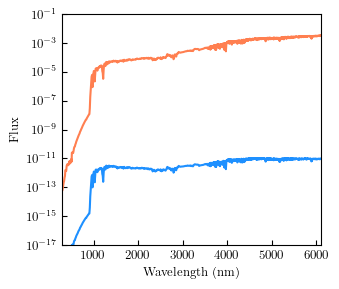

In [7]:
ssp_path = '/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/spectra_young.csv'

spectrum = pd.read_csv(ssp_path)


plt.figure(figsize=(10/3, 3))
for i, col in enumerate(spectrum.columns[1:]):
    plt.plot(spectrum['wave'], spectrum[col], label=col, lw=1.5)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux')
plt.xlim(300, 6100)
plt.yscale('log')
plt.ylim(1e-17, 1e-1)

In [8]:
class NebularModel:
    def __init__(self, isoc_type, cloudy_dust, sps_home, csp_lambda,
                mypi, smooth_velocity=True, nebnz=11, nebnage=10, nebnip=7, nebular_smooth_init=100.0):
        self.csp_lambda = jnp.asarray(csp_lambda)
        self.nspec = self.csp_lambda.size
        self.mypi = mypi
        self.smooth_velocity = smooth_velocity
        self.nebular_smooth_init = nebular_smooth_init
        self.nebnz = nebnz
        self.nebnage = nebnage
        self.nebnip = nebnip

        # File paths
        suffix = 'WD' if cloudy_dust else 'ND'
        base = Path(sps_home) / 'nebular' / f'ZAU_{suffix}_{isoc_type}'
        self.cont_file = base.with_suffix('.cont')
        self.line_file = base.with_suffix('.lines')

        # Load data
        self._load_continuum()
        self._load_lines()
        self._compute_resolution_elements()
        self._build_gaussians()

    def _load_continuum(self): 
        with open(self.cont_file, 'r') as f:
            f.readline()
            readlambneb = np.array([float(x) for x in f.readline().split()])
            nlam = len(readlambneb)
            self.readlambneb = jnp.asarray(readlambneb)

            lines = f.readlines()
            cont_cube = np.zeros((self.nspec, self.nebnz, self.nebnage, self.nebnip))
            logz_grid = np.zeros(self.nebnz)
            logu_grid = np.zeros(self.nebnip)
            age_grid = np.zeros(self.nebnage)


            idx = 0
            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        parts = [float(x) for x in lines[idx].split()]
                        logz_grid[i], age_grid[j], logu_grid[k] = parts[:3]
                        idx += 1
                        cont = np.array([float(x) for x in lines[idx].split()]) #Units are Lsun/Hz/Q
                        logcont = np.log10(cont + 10**-95)
                        cont_interp = jnp.interp(self.csp_lambda, readlambneb, logcont)
                        cont_cube[:, i, j, k] = cont_interp
                        idx += 1

            self.nebem_cont = jnp.asarray(cont_cube)
            self.nebem_logz = jnp.asarray(logz_grid)
            self.nebem_logu = jnp.asarray(logu_grid)
            self.nebem_age = jnp.log10(jnp.asarray(age_grid))

    def _load_lines(self):
        with open(self.line_file, 'r') as f:
            f.readline()
            self.nebem_line_pos = jnp.array([float(x) for x in f.readline().split()])
            self.nemline = self.nebem_line_pos.shape[0]
            line_cube = np.zeros((self.nemline, self.nebnz, self.nebnage, self.nebnip))

            for i in range(self.nebnz):
                for j in range(self.nebnage):
                    for k in range(self.nebnip):
                        f.readline()
                        linevals = np.array([float(x) for x in f.readline().split()])
                        line_cube[:, i, j, k] = np.log10(linevals + 10**-95)

            self.nebem_line = jnp.asarray(line_cube)

    def _compute_resolution_elements(self):
        idx = jnp.clip(jnp.searchsorted(self.csp_lambda, self.nebem_line_pos) - 1, 1, self.nspec - 2)
        dlam = self.csp_lambda[idx + 1] - self.csp_lambda[idx]
        self.neb_res_min = jnp.full_like(dlam, 1) #jnp.asarray(dlam)
        

    def _build_gaussians(self):
        # Broadcast wavelength grid and line centers for vectorized operations
        csp_lambda_exp = self.csp_lambda[:, None]  # shape (N_lambda, 1)
        nebem_line_pos_exp = self.nebem_line_pos[None, :]  # shape (1, nemline)
        
        if self.smooth_velocity:# smoothing variable is km/s
            dlam = self.nebem_line_pos * self.nebular_smooth_init / (c * 1e13)
        else: # smoothing variable is in Angstrom
            dlam = jnp.full_like(self.nebem_line_pos, self.nebular_smooth_init)
        
        # Clamp dlam
        dlam = jnp.maximum(dlam, self.neb_res_min * 2)  # shape (nemline,)
        
        dlam_exp = dlam[None, :]  # shape (1, nemline) for broadcasting
        
        # Calculate Gaussian profiles for all lines at once
        prof = jnp.exp(-((csp_lambda_exp - nebem_line_pos_exp)**2) / 2 / dlam_exp**2)/(jnp.sqrt(2 * self.mypi) * dlam_exp)
        
        # Normalize profiles: flux conservation in velocity space
        # norm_factor = jnp.sqrt(2 * self.mypi) * dlam_exp * c * nebem_line_pos_exp**2  # shape (1, nemline)
        # prof /= norm_factor

        prof = prof * csp_lambda_exp**2 / (c * 1e10)  # Convert to erg/s/cm²/Å
        
        self.gaussnebarr = prof  # shape (N_lambda, nemline)


    def evaluate(self, logZ, logU, logage, Q):

        # Locate and compute fractional offsets in grid
        z1 = locate(logZ, self.nebem_logz)
        dz = jnp.clip((logZ - self.nebem_logz[z1]) / (self.nebem_logz[z1 + 1] - self.nebem_logz[z1]), 0.0, 1.0)

        u1 = locate(logU, self.nebem_logu)
        du = jnp.clip((logU - self.nebem_logu[u1]) / (self.nebem_logu[u1 + 1] - self.nebem_logu[u1]), 0.0, 1.0)

        a1 = locate(logage, self.nebem_age)
        da = jnp.clip((logage - self.nebem_age[a1]) / (self.nebem_age[a1 + 1] - self.nebem_age[a1]), 0.0, 1.0)

        # Compute log10(Q), ensuring correct dtype
        logQ = math.log10(Q)
        
        # Interpolate log-continuum and line luminosity
        logcont_interp = trilinear_interp(self.nebem_cont, z1, dz, a1, da, u1, du)
        loglines_interp = trilinear_interp(self.nebem_line, z1, dz, a1, da, u1, du)

        # Combine with logQ
        log_cont_flux = logcont_interp + logQ
        log_line_flux = loglines_interp + logQ
        
        # Convert to linear only where absolutely necessary
        cont_flux = 10 ** log_cont_flux  # shape (nspec,)
        line_flux = 10 ** log_line_flux  # shape (nlines,)
        
        # Combine lines
        line_spec = jnp.dot(self.gaussnebarr, line_flux)   # shape (nspec,)
        self.linespec = line_spec  # Store for later use if needed
        self.conflux = cont_flux  # Store for later use if needed
        self.lineflux = line_flux  # Store for later use if needed

        # Final SED
        spec = cont_flux + line_spec  # both in erg/s/cm²/Å

        return spec

    def get_neb_spec(self, logZ, logU, logage, spectrum, wavelength, frac_obrun=0.0):
        """
        Get the nebular spectrum for given metallicity, ionization parameter, age, and ionizing photon rate.

        Parameters
        ----------
        logZ : float
            Logarithmic metallicity (Z/Zsun)
        logU : float
            Logarithmic ionization parameter (dimensionless)
        logage : float
            Logarithmic age of the stellar population (years)
        Q : float
            Ionizing photon production rate (photons/s)

        Returns
        -------
        spec : array (nspec,)
            Nebular spectrum in erg/s/cm²/Å
        """
        Q = get_qq(spectrum, wavelength, frac_obrun)
        print('we found the Q', Q)
        return self.evaluate(logZ, logU, logage, Q)
    
def locate(x, grid):
    return jnp.clip(jnp.searchsorted(grid, x) - 1, 0, grid.size - 2)

def trilinear_interp(cube, z1, dz, a1, da, u1, du):
    """
    Trilinear interpolation on a 4D cube: shape (nspec, nz, nage, nu)
    """
    # Interpolation weights for the 8 surrounding points
    w = jnp.array([
        (1 - dz) * (1 - da) * (1 - du),
        (1 - dz) * (1 - da) * du,
        (1 - dz) * da * (1 - du),
        (1 - dz) * da * du,
        dz * (1 - da) * (1 - du),
        dz * (1 - da) * du,
        dz * da * (1 - du),
        dz * da * du
    ])

    # Stack the 8 corners along a new axis (0), each of shape (nspec,)
    slices = jnp.stack([
        cube[:, z1,   a1,   u1],
        cube[:, z1,   a1,   u1+1],
        cube[:, z1,   a1+1, u1],
        cube[:, z1,   a1+1, u1+1],
        cube[:, z1+1, a1,   u1],
        cube[:, z1+1, a1,   u1+1],
        cube[:, z1+1, a1+1, u1],
        cube[:, z1+1, a1+1, u1+1]
    ], axis=0)  # shape (8, nspec)

    # Weighted sum over the 8 corners
    return jnp.sum(w[:, None] * slices, axis=0)  # shape (nspec,)

def get_qq(spectrum, wavelengths, frac_obrun):
    """
    Compute the ionizing photon production rate Q from a stellar spectrum.

    Parameters
    ----------
    spectrum : array-like
        Stellar spectrum in units of L_sun / Hz (i.e., solar luminosity per unit frequency)
    wavelengths : array-like
        Wavelength array in Angstrom
    frac_obrun : float
        Fraction of OB stars that are runaways (not embedded in HII regions)

    Returns
    -------
    qq : float
        Ionizing photon production rate in photons/s
    """
    # Mask for ionizing photons: λ < 911.6 Å (Lyman limit)
    mask = wavelengths < 911.6

    spec_nu = c / (wavelengths * 1e-10)
    spec_nu = spec_nu[mask]

    #spec_ion = spectrum[mask] / spec_nu * wavelengths[mask]
    spec_ion = spectrum[mask] * wavelengths[mask]**2 / (c*1e10)

    qq = -jnp.trapezoid(spec_ion, spec_nu)  

    # Correct for OB star runaway fraction: these stars do not contribute ionizing photons
    qq *= (1.0 - frac_obrun)

    # Convert unitless Q (in L_sun / h) to physical units: photons/s
    # Multiply by L_sun / h and take log10 for numerical stability
    return 10 ** (math.log10(qq) - math.log10(h.value) + math.log10(L_sun.value))


In [9]:
import typing
import h5py
import numpy as np
import jax.numpy as jnp
from jax import jit
from dataclasses import dataclass

# Import fsps and check availability
try:
    import fsps
    HAS_FSPS = True
except (ImportError, RuntimeError):
    HAS_FSPS = False

    
def collect_ssp_data(**kwargs) -> typing.Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """
    Collects Simple Stellar Population (SSP) data using the SSPBasis class and 
    adds an extra SSP with log age -6 because zero age SSPs are not available in FSPS. 

    The new SSP with log age -6 is inserted at the beginning of the age and flux arrays.

    Parameters
    ----------
    **kwargs : dict
        Keyword arguments to configure the SSPBasis object.

    Returns
    -------
    Tuple of jnp.ndarray:
        - ssp_lgmet : 1D array of log10(Z) representing the metallicities.
        - ssp_lg_age_gyr : 1D array of log10(age/Gyr) for the SSP templates, including the new SSP with log age -6.
        - ssp_wave : 1D array of wavelength values for the SSP spectra.
        - ssp_flux : 3D array containing the spectral fluxes for each metallicity, including the new SSP.
    """
    if not HAS_FSPS:
        raise ImportError("FSPS is required for SSP data collection but is not installed.")

    # Initialize the SSPBasis object
    ssp = SSPBasis(zcontinuous=0, sfh=0, **kwargs)

    # Retrieve logarithmic metallicity and age data
    ssp_lgmet = jnp.log10(ssp.ssp.zlegend)
    nzmet = ssp_lgmet.size
    ssp_lg_age_gyr = ssp.ssp.log_age - 9.0  # Log age in Gyr

    # Identify the index where log age is -4
    age_minus_4_idx = np.where(ssp_lg_age_gyr == -4)[0][0]

    # Collect spectral data for each metallicity
    spectrum_collector = []
    for zmet_indx in range(1, nzmet + 1):
        print(f"...retrieving zmet = {zmet_indx} of {nzmet}")
        _wave, _fluxes, _ = ssp.get_galaxy_spectrum(zmet=zmet_indx)
        spectrum_collector.append(_fluxes)

    # Convert collected data to JAX arrays
    ssp_wave = jnp.array(_wave)
    ssp_flux = jnp.array(spectrum_collector)

    # Step 1: Duplicate the SSP with age -4 to create one with age -6
    # Select flux corresponding to log age -4 for all metallicities
    duplicated_flux = ssp_flux[:, age_minus_4_idx, :]  # Shape: (nzmet, wavelength)

    # Step 2: Modify the age to log age -6 and insert it at the beginning of ssp_lg_age_gyr
    new_age = -6
    ssp_lg_age_gyr = np.insert(ssp_lg_age_gyr, 0, new_age)

    # Step 3: Insert the duplicated flux at the beginning of ssp_flux for each metallicity
    ssp_flux = np.concatenate([duplicated_flux[:, np.newaxis, :], ssp_flux], axis=1)

    # Convert the updated arrays to JAX arrays
    ssp_lg_age_gyr = jnp.array(ssp_lg_age_gyr)
    ssp_flux = jnp.array(ssp_flux)

    return ssp_lgmet, ssp_lg_age_gyr, ssp_wave, ssp_flux


def collect_ssp_data_wrapper(**kwargs) -> SSPData:
    """
    Wrapper function to collect Simple Stellar Population (SSP) data and return it
    as an SSPData object.

    This function calls the lower-level JIT-compiled function `collect_ssp_data` 
    to retrieve the SSP data in the form of JAX arrays. It then wraps the data into 
    an SSPData dataclass for easy access and further usage.

    Parameters
    ----------
    **kwargs : dict
        Keyword arguments passed to the `collect_ssp_data` function to configure
        the SSPBasis object.

    Returns
    -------
    SSPData
        A frozen dataclass containing the SSP data, including metallicity, age,
        wavelength, and flux arrays.
    """
    # Collect SSP data in the form of JAX arrays
    ssp_lgmet, ssp_lg_age_gyr, ssp_wave, ssp_flux = collect_ssp_data(**kwargs)

    # Return the data wrapped in an SSPData dataclass
    return SSPData(ssp_lgmet, ssp_lg_age_gyr, ssp_wave, ssp_flux)

In [10]:
ssp = SSPBasis(zcontinuous=0, sfh=0)

In [11]:
ssp_lgmet = jnp.log10(ssp.ssp.zlegend)
nzmet = ssp_lgmet.size
ssp_lg_age_gyr = ssp.ssp.log_age - 9.0  # Log age in Gyr


age_minus_4_idx = np.where(ssp_lg_age_gyr == -4)[0][0]

In [17]:
import astropy.constants as const

In [20]:
spectrum_collector = []
spectrum_collector_aa = []
for zmet_indx in range(1, nzmet + 1):
    print(f"...retrieving zmet = {zmet_indx} of {nzmet}")
    _wave, _fluxes, _ = ssp.get_galaxy_spectrum(zmet=zmet_indx, peraa = False)
    factor = const.c * 1e10 / _wave**2
    spectrum_collector.append(_fluxes)
    spectrum_collector_aa.append(_fluxes * factor)

ssp_wave = jnp.array(_wave)
ssp_flux = jnp.array(spectrum_collector)
ssp_flux_aa = jnp.array(spectrum_collector_aa)

...retrieving zmet = 1 of 12
...retrieving zmet = 2 of 12
...retrieving zmet = 3 of 12
...retrieving zmet = 4 of 12
...retrieving zmet = 5 of 12
...retrieving zmet = 6 of 12
...retrieving zmet = 7 of 12
...retrieving zmet = 8 of 12
...retrieving zmet = 9 of 12
...retrieving zmet = 10 of 12
...retrieving zmet = 11 of 12
...retrieving zmet = 12 of 12


In [21]:
ssp_flux - ssp_flux_aa

Array([[[-6.23371910e-11, -1.56715377e-10, -2.88763846e-10, ...,
         -2.98775518e-19, -2.87930947e-19, -2.77463028e-19],
        [-4.88255582e-11, -1.22586150e-10, -2.25699862e-10, ...,
         -2.73297424e-19, -2.63377900e-19, -2.53802509e-19],
        [-6.10466191e-11, -1.53547758e-10, -2.83014057e-10, ...,
         -2.50414196e-19, -2.41325523e-19, -2.32551877e-19],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -6.84403261e-21, -6.59561186e-21, -6.35585186e-21],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -6.62190877e-21, -6.38154979e-21, -6.14957248e-21],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -6.13710742e-21, -5.91434623e-21, -5.69935237e-21]],

       [[-4.90603044e-11, -1.32914776e-10, -2.54443883e-10, ...,
         -3.09165242e-19, -2.97942934e-19, -2.87111289e-19],
        [-5.45804409e-11, -1.47963100e-10, -2.83349039e-10, ...,
         -2.81558167e-19, -2.71338299e

In [23]:
duplicated_flux = ssp_flux[:, age_minus_4_idx, :]  # Shape: (nzmet, wavelength)
duplicated_flux_aa = ssp_flux_aa[:, age_minus_4_idx, :]  # Shape: (nzmet, wavelength)
# Step 2: Modify the age to log age -6 and insert it at the beginning of ssp_lg_age_gyr
new_age = -6
ssp_lg_age_gyr = np.insert(ssp_lg_age_gyr, 0, new_age)

# Step 3: Insert the duplicated flux at the beginning of ssp_flux for each metallicity
ssp_flux = np.concatenate([duplicated_flux[:, np.newaxis, :], ssp_flux], axis=1)
ssp_flux_aa = np.concatenate([duplicated_flux_aa[:, np.newaxis, :], ssp_flux_aa], axis=1)
# Convert the updated arrays to JAX arrays
ssp_lg_age_gyr = jnp.array(ssp_lg_age_gyr)
ssp_flux = jnp.array(ssp_flux)
ssp_flux_aa = jnp.array(ssp_flux_aa)

In [27]:
from ceridwen.ssps.ssp_data import SSPData

ssp_data = SSPData(ssp_lgmet, ssp_lg_age_gyr, ssp_wave, ssp_flux, ssp_flux_aa)
ssp_data.save('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

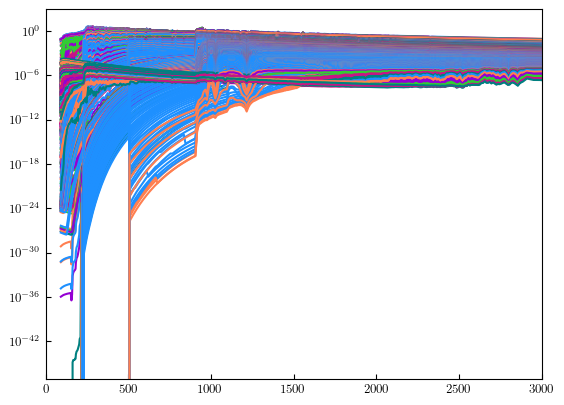

In [25]:
for a in range(len(ssp_data.ssp_lg_age_gyr)):
    for m in range(len(ssp_data.ssp_lgmet)):
        plt.plot(ssp_wave, ssp_flux_aa[m, a, :])

plt.xlim(0, 3000)
plt.yscale('log')